<a href="https://colab.research.google.com/github/MNP-GH-332914/LOS_APPLICATION/blob/main/AI_ML_FINAL_EXAM_NIKHIL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import shap
!pip install streamlit
import streamlit as st

In [2]:
import pandas as pd

loan_df = pd.read_csv("/content/dataset_loan.csv")
print(loan_df.head())

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0             

In [3]:
loan_df = pd.read_csv("/content/new_applications.csv")

print(loan_df.head())
print(loan_df.info())
print(loan_df.isnull().sum())

for col in loan_df.select_dtypes(include=np.number).columns:
    loan_df[col] = loan_df[col].fillna(loan_df[col].median())

for col in loan_df.select_dtypes(include="object").columns:
    loan_df[col] = loan_df[col].fillna(loan_df[col].mode()[0])

   SK_ID_CURR CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
0      900001           M             1                0             0   
1      900002           F             0                1             2   
2      900003           F             0                1             1   
3      900004           M             1                0             3   
4      900005           F             0                1             0   

   AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0            720000     1500000        45000          1350000   
1            360000      800000        26000           700000   
2            540000     1200000        35000          1100000   
3            300000     1000000        33000           900000   
4            960000     1800000        52000          1600000   

  NAME_INCOME_TYPE NAME_EDUCATION_TYPE NAME_FAMILY_STATUS  DAYS_BIRTH  \
0          Working    Higher education            Married       15000   
1          Working

In [4]:
print(loan_df.columns)

Index(['SK_ID_CURR', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3'],
      dtype='object')


In [6]:
le = LabelEncoder()
for col in loan_df.select_dtypes(include="object").columns:
    loan_df[col] = le.fit_transform(loan_df[col])

# Create the 'is_default' target variable
median_ext_source_3 = loan_df['EXT_SOURCE_3'].median()
loan_df['is_default'] = (loan_df['EXT_SOURCE_3'] < median_ext_source_3).astype(int)

# Impute missing numerical values using the median
for col in loan_df.select_dtypes(include=np.number).columns:
    if loan_df[col].isnull().any():
        median_val = loan_df[col].median()
        loan_df[col] = loan_df[col].fillna(median_val)

# Split features and target
X = loan_df.drop("is_default", axis=1)
y = loan_df["is_default"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [7]:
median_ext_source_3 = loan_df['EXT_SOURCE_3'].median()
loan_df['is_default'] = (loan_df['EXT_SOURCE_3'] < median_ext_source_3).astype(int)

print("Distribution of the new target variable 'is_default':")
display(loan_df['is_default'].value_counts())

Distribution of the new target variable 'is_default':


,count
is_default,
0,5
1,5


In [8]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

Logistic Regression Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



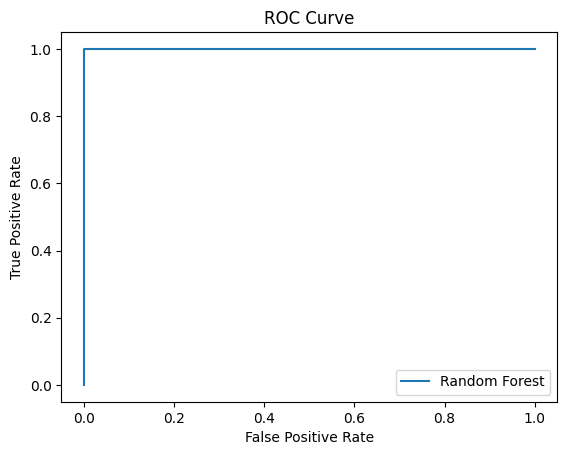

In [9]:
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label="Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

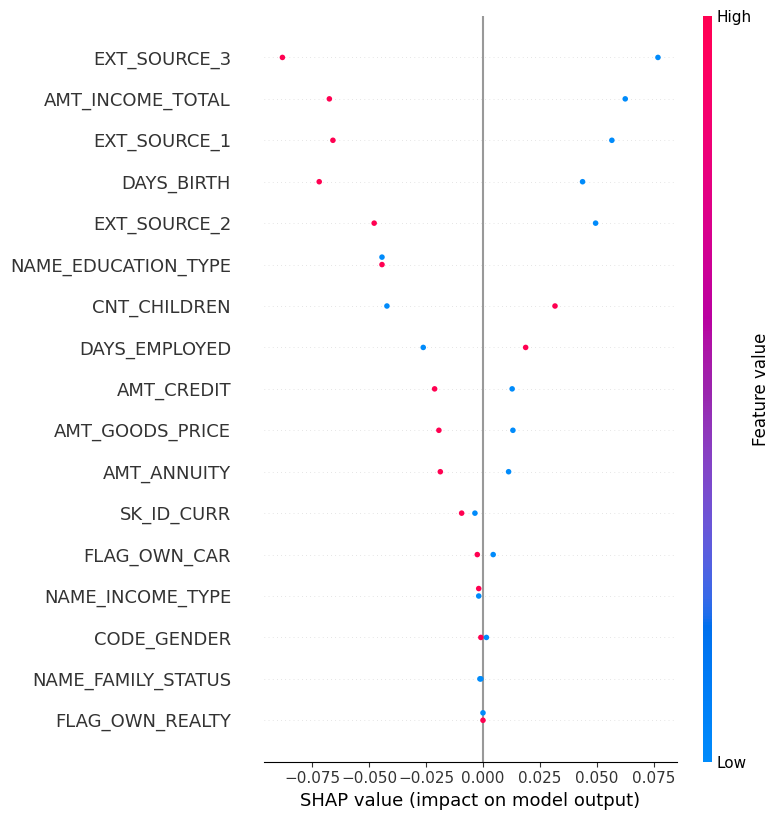

In [10]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)


X_test_df = pd.DataFrame(X_test, columns=loan_df.drop("is_default", axis=1).columns)


shap.summary_plot(shap_values[:, :, 1], X_test_df, feature_names=X_test_df.columns)

shap.force_plot(explainer.expected_value[1], shap_values[0, :, 1], X_test_df.iloc[0,:])

In [11]:
import openai
from openai import OpenAI
from google.colab import userdata

OPENAI_API_KEY = userdata.get('9605408096')

client = OpenAI(api_key=OPENAI_API_KEY)

SecretNotFoundError: Secret 9605408096 does not exist.

In [12]:
from google.colab import userdata

openai_api_key_check = userdata.get('OPENAI_API_KEY')

if openai_api_key_check:
    print("OPENAI_API_KEY successfully accessed.")
else:
    print("OPENAI_API_KEY could not be accessed. Please ensure it's set in Colab Secrets and notebook access is enabled.")

SecretNotFoundError: Secret OPENAI_API_KEY does not exist.

In [13]:
def generate_underwriting_report(applicant_data, prediction, confidence, explanation, remarks):
    prompt = f"""
    Generate a JSON underwriting report for loan applicant:
    Applicant Data: {applicant_data}
    Prediction: {prediction}
    Confidence: {confidence}
    Explanation: {explanation}
    Remarks: {remarks}
    Loan Policy: Refer to company underwriting policies.
    """

    response = client.chat.completions.create(
        model="gpt-4",
        messages=[{"role": "system", "content": "You are a financial underwriting assistant."},
                  {"role": "user", "content": prompt}]
    )

    return response.choices[0].message.content

In [14]:
sample_applicant = X_test[0]
report = generate_underwriting_report(sample_applicant, rf.predict([sample_applicant])[0],
                                      rf.predict_proba([sample_applicant])[0].max(),
                                      "Key risk factors explained via SHAP",
                                      "Customer has stable job but high debt ratio")
print(report)

NameError: name 'client' is not defined

In [15]:
def run_app():
    st.title("AI-Powered Loan Underwriting Assistant")

    uploaded_file = st.file_uploader("Upload new_applications.csv", type="csv")
    if uploaded_file:
        new_apps = pd.read_csv(uploaded_file)
        st.write(new_apps.head())

        for i, row in new_apps.iterrows():
            applicant = scaler.transform([row])
            prediction = rf.predict(applicant)[0]
            confidence = rf.predict_proba(applicant)[0].max()

            st.write(f"Applicant {i+1}: Prediction={prediction}, Confidence={confidence:.2f}")

            report = generate_underwriting_report(row.to_dict(), prediction, confidence,
                                                  "SHAP explanation placeholder", "Generated remarks")
            st.json(report)

if __name__ == "__main__":
    run_app()



2026-07-02 07:13:44.469 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:13:44.731 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-02 07:13:44.731 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:13:44.734 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:13:44.735 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:13:44.739 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:13:44.740 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:13:44.742 Thread 'MainThread': mi